In [14]:
!pip install simpy pandas numpy scikit-learn matplotlib seaborn


In [39]:
import simpy
import random
import numpy as np
import pandas as pd



In [40]:
def service_center(env, servers, service_time, wait_times):
    arrival_time = env.now
    with servers.request() as request:
        yield request
        wait_times.append(env.now - arrival_time)
        yield env.timeout(random.expovariate(1 / service_time))

def customer_generator(env, arrival_rate, servers, service_time, wait_times):
    while True:
        yield env.timeout(random.expovariate(arrival_rate))
        env.process(service_center(env, servers, service_time, wait_times))

def run_simulation(arrival_rate, service_time, num_servers, sim_time=1000):
    env = simpy.Environment()
    servers = simpy.Resource(env, capacity=num_servers)
    wait_times = []
    env.process(customer_generator(env, arrival_rate, servers, service_time, wait_times))
    env.run(until=sim_time)
    return np.mean(wait_times) if wait_times else 0

data = []

for _ in range(1000):
    arrival_rate = random.uniform(1, 10)
    service_time = random.uniform(1, 8)
    num_servers = random.randint(1, 5)

    avg_wait = run_simulation(arrival_rate, service_time, num_servers)

    data.append([arrival_rate, service_time, num_servers, avg_wait])

df = pd.DataFrame(data, columns=[
    "Arrival_Rate", "Service_Time", "Servers", "Avg_Waiting_Time"
])

df.to_csv("simulation_data.csv", index=False)
df.head()


,Arrival_Rate,Service_Time,Servers,Avg_Waiting_Time
0,1.647321,1.976218,4,1.926462
1,3.132332,7.809514,2,444.198899
2,4.170532,6.475504,3,445.155570
3,2.334541,7.772127,5,376.078550
4,2.971458,7.242021,4,383.456297


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import time




In [42]:
X = df[["Arrival_Rate", "Service_Time", "Servers"]]
y = df["Avg_Waiting_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    preds = model.predict(X_test)
    pred_time = time.time() - start

    mse = mean_squared_error(y_test, preds)
    rmse = mse ** 0.5

    r2 = r2_score(y_test, preds)

    results.append([name, rmse, r2, train_time, pred_time])

results_df = pd.DataFrame(results, columns=[
    "Model", "RMSE", "R2", "Training Time", "Prediction Time"
])

results_df

,Model,RMSE,R2,Training Time,Prediction Time
0,Linear Regression,61.744977,0.715168,0.002981,0.001616
1,Decision Tree,33.414095,0.916585,0.007432,0.002623
2,Random Forest,22.843901,0.961012,0.523750,0.019396
3,Gradient Boosting,23.122484,0.960056,0.219708,0.002851
4,SVR,87.921218,0.422472,0.058443,0.014751
5,KNN,21.110170,0.966706,0.002241,0.002785


In [43]:
results_df.to_csv("results.csv", index=False)
print("CSV saved successfully")


CSV saved successfully


In [44]:
!pip install Topsis-Dhruv-102303785


In [45]:
!topsis results.csv 0.35,0.35,0.15,0.15 -,+,-,- topsis_result.csv


TOPSIS analysis completed successfully


/tmp/ipython-input-1526840776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2", y="Model", data=results_df.sort_values(by="R2", ascending=False), palette="viridis")


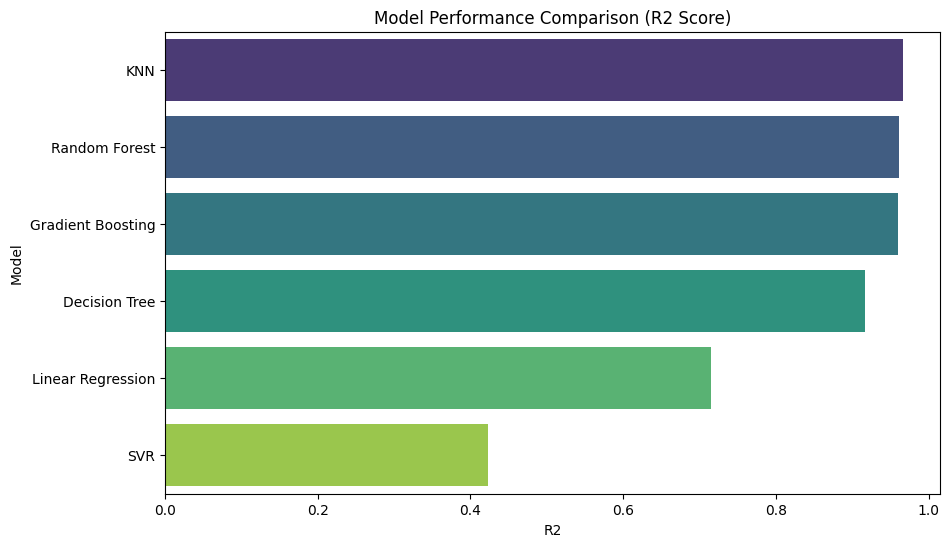

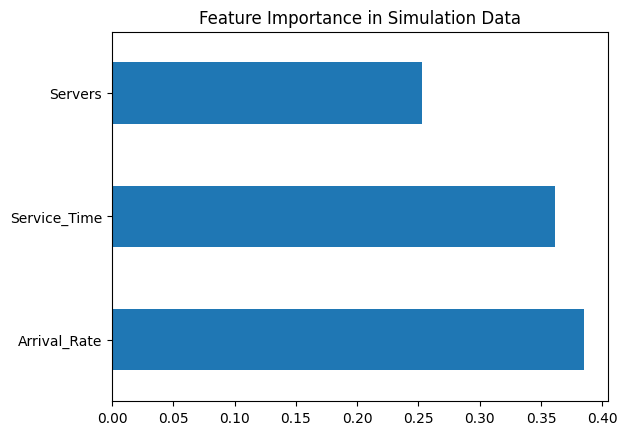

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.barplot(x="R2", y="Model", data=results_df.sort_values(by="R2", ascending=False), palette="viridis")
plt.title("Model Performance Comparison (R2 Score)")
plt.savefig("model_comparison.png")
plt.show()


best_rf = models["Random Forest"]
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_importances.nlargest(3).plot(kind='barh')
plt.title("Feature Importance in Simulation Data")
plt.savefig("feature_importance.png")